import library......

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## here load file.....

In [51]:
df = pd.read_csv(r"titanic (1).csv")
df


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [61]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,Third,man,True,Southampton,no,True


In [60]:
df.tail()    ## check bottum 5 rows....

,survived,pclass,sex,age,sibsp,parch,fare,class,who,adult_male,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,Second,man,True,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,First,woman,False,Southampton,yes,True
888,0,3,female,28.0,1,2,23.45,Third,woman,False,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,First,man,True,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Third,man,True,Queenstown,no,True


In [59]:
df.isnull().sum()### check missing values....

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

# WE ARE removing 'deck 'cloumns because 688 out of 891 valves missing....(77 % empty)
# if we keep it , model will not lrean well . so better drop this columns

In [55]:
df=df.drop("deck", axis = 1) 

# both 'embark and embark_town show same information  - boarding place.....
#embark has code (  C , Q, S) and embark_town has full city name.
keeping both will create duplicate data so will remove embark_town column.
we keep 'embarked' because itis simple and short .


In [56]:
## 1- 
df  = df.drop("embarked" , axis = 1)    ### this colunm remove is because it is show duplicate values......

## for age colnms ,177 values are missing .
I fill missing age with median . median is middle values.
I used median not mean becouse age has outliers like babies (0 years) and old p (80 years ).
median is more safe and dose not get affected by outliers. 

In [57]:
df['age'] = df['age'].fillna(df['age'].median())

# Embarked and embark_town show same place of info so i kept one and removed duplicates to clean data.

In [ ]:
df['embark_town']=df['embark_town'].fillna(df['embark_town'].mode()[0])

## filled 2 missing values in embark_town with most comman port (southampton)

In [ ]:
df.shape  ## check rows and columns - 891 rows , 13 columns after cleaning . 2 colunms dropped
# output: (891 , 13 )- 891 passengers , 13 columns .......

(891, 13)

In [ ]:
df.size  # check total cell in dataset = rows * columns = 891 * 13 = 11583 

11583

In [66]:
df.dtypes ## check data types in each columns : - int , float , object etc.
## to know which column is numeric and which is categorical for encoding and model.

survived         int64
pclass           int64
sex                str
age            float64
sibsp            int64
parch            int64
fare           float64
class              str
who                str
adult_male        bool
embark_town        str
alive              str
alone             bool
dtype: object

In [67]:
df.describe()  # shows summaryof numerical columns - mean , min , max , count etc.
## to check average age , fare and find outliers. 

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## here create  a charts.....

# 1 - How many survived or died

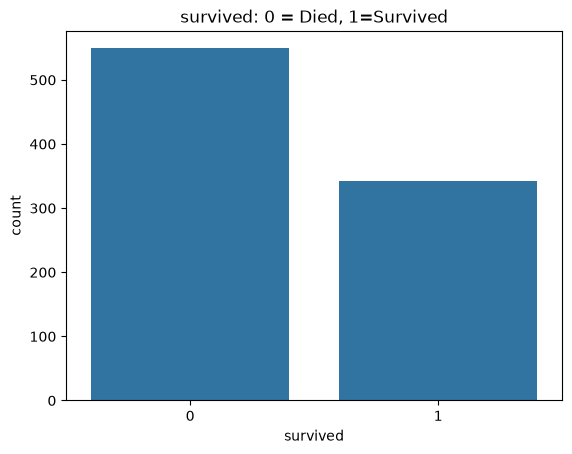

In [69]:
sns.countplot (x = 'survived',data= df)
plt.title("survived: 0 = Died, 1=Survived")
plt.show()                                           ## Show more people died than Survived.......

## why uesd countplot: to count how many survived vs died
## what is show : more  died then survived 

# 2 - Gender vs survival - most most important chat


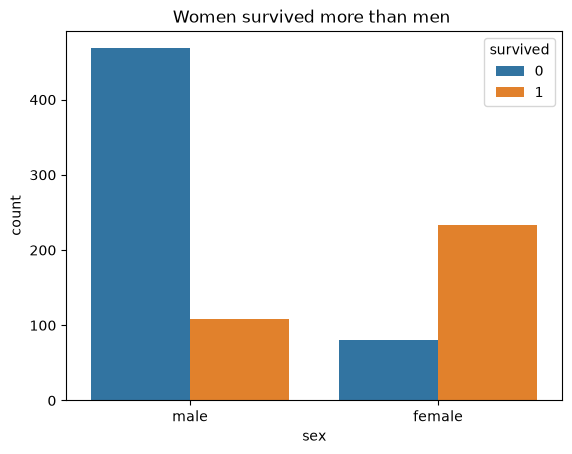

In [70]:
sns.countplot(x='sex',hue='survived',data=df)
plt.title("Women survived more than men ")
plt.show()        ## proves women and children first rule

# chart 2 : countplot with hue : sex vs survived
# why uesd hue : to compare two columns (sex and survived) 
# why it show : women survived more men died more 

## 3 - pclass vs survival


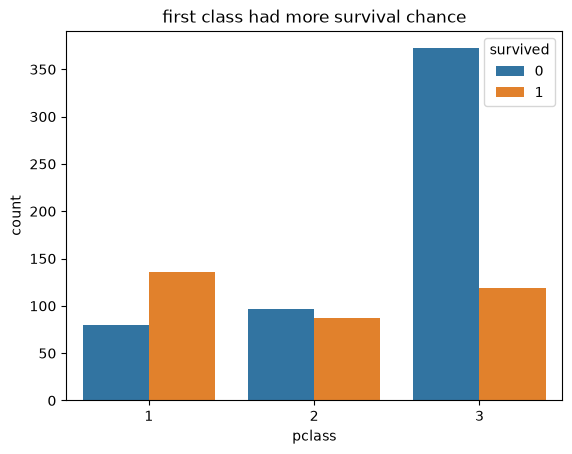

In [71]:
sns.countplot(x='pclass',hue='survived',data=df)
plt.title("first class had more survival chance")
plt.show()               # rich people had more chance because they we near lifeboats

# 3 :- countplot with hue:- pclass vs survived
# why uesd:- to see if rech people had more chance
# what it show :- first class (1) survived more than third class(3)